# 1. Retrieval-Augmented Generation for Financial Question Answering over Company 10-K Filings

This project builds a Retrieval-Augmented Generation (RAG) system that allows users to ask natural-language questions about company 10-K filings. The system retrieves relevant filing passages from a local vector database and uses a language model to generate source-grounded answers.

Companies used:
- Apple
- Amazon
- Nvidia

Years used:
- 2024
- 2025

### Concise Description

We build a RAG-based financial research assistant for company 10-K filings. The system combines semantic search with language generation. Given a user question, the system embeds the query, searches a vector database of 10-K filing chunks, retrieves the most relevant passages, and generates a concise answer using the retrieved context.

This application is useful for financial research because 10-K filings are long, dense, and difficult to search manually. RAG allows users to ask questions about risks, competition, regulation, supply chains, and macroeconomic exposure while grounding the answer in actual filing text.

### Key Components of the RAG Model

The RAG system has five main components:

1. Document processing: extracts text from 10-K PDFs.
2. Chunking: splits long filings into smaller passages.
3. Embedding model: converts each chunk into a numerical vector.
4. Vector database: stores vectors, metadata, and source text.
5. Generator: uses retrieved context to answer the user's question.

Mathematically, retrieval is based on vector similarity. Given a query embedding q and document chunk embedding dᵢ, the retriever ranks chunks by similarity:

cos(q, dᵢ) = (q · dᵢ) / (||q|| ||dᵢ||)

The highest-ranked chunks are passed into the language model as context.

### Train / Build Description

This project does not train a large language model from scratch. Instead, we build a RAG system by constructing a searchable vector index over company filings.

The build process is:

1. Load 10-K PDFs.
2. Extract text page-by-page.
3. Split pages into overlapping chunks.
4. Convert each chunk into an embedding vector.
5. Store embeddings, text, and metadata in ChromaDB.
6. Embed user questions.
7. Retrieve the most similar chunks using vector similarity search.
8. Pass retrieved chunks into a language model for answer generation.

The main tunable parameters are chunk size, chunk overlap, number of retrieved chunks, company/year filters, and prompt design.

## 2. Data Collection

The source filings are stored as PDFs in `../data/raw`.

### Data Description

The dataset consists of six company 10-K filings in PDF format. The filings are stored locally in `data/raw`.

Files used:
- amazon24.pdf
- amazon25.pdf
- apple24.pdf
- apple25.pdf
- nvidia24.pdf
- nvidia25.pdf

Each filing is parsed page-by-page. For every page, we store:
- company
- filing year
- source file
- page number
- extracted text

After extraction, pages are split into overlapping text chunks. These chunks become the searchable units in the RAG system.

## 3. PDF Processing

Each PDF is read page by page, converted into LangChain `Document` objects, and tagged with company, year, source file, and page metadata.

In [3]:
from pathlib import Path
from pypdf import PdfReader
from langchain_core.documents import Document

raw_dir = Path("../data/raw")

docs = []

for pdf_path in raw_dir.glob("*.pdf"):
    reader = PdfReader(str(pdf_path))
    
    company = pdf_path.stem[:-2]
    year = "20" + pdf_path.stem[-2:]
    
    for page_num, page in enumerate(reader.pages, start=1):
        text = page.extract_text()
        
        if text and text.strip():
            docs.append(
                Document(
                    page_content=text,
                    metadata={
                        "source_file": pdf_path.name,
                        "company": company,
                        "year": year,
                        "page": page_num
                    }
                )
            )

len(docs)

605

## 4. Chunking Strategy

Page-level documents are split into overlapping text chunks to preserve context across chunk boundaries.

Because full 10-K filings are too long to search or pass into a language model directly, we split each page into overlapping character-based chunks.

We use:
- chunk size: 1000 characters
- overlap: 150 characters

The overlap helps preserve context across chunk boundaries.

In [4]:
from langchain_core.documents import Document

def chunk_text(text, chunk_size=1000, chunk_overlap=150):
    chunks = []
    start = 0
    
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start += chunk_size - chunk_overlap
    
    return chunks

chunks = []

for doc in docs:
    text_chunks = chunk_text(
        doc.page_content,
        chunk_size=1000,
        chunk_overlap=150
    )
    
    for i, chunk in enumerate(text_chunks):
        chunks.append(
            Document(
                page_content=chunk,
                metadata={
                    **doc.metadata,
                    "chunk_id": i
                }
            )
        )

len(chunks)

2878

## 5. Embedding Generation

SentenceTransformer creates dense vector representations for the document chunks.

## Embedding Model and Vector Database

We use `sentence-transformers/all-MiniLM-L6-v2` to embed both document chunks and user queries. The embeddings are stored in ChromaDB, a local persistent vector database. ChromaDB allows us to perform semantic similarity search over the 10-K chunks.

In [5]:
from sentence_transformers import SentenceTransformer
import chromadb
from tqdm import tqdm

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

client = chromadb.PersistentClient(path="../data/chroma_db")

collection = client.get_or_create_collection(
    name="company_10k_filings"
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [6]:
from sentence_transformers import SentenceTransformer
import chromadb

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

client = chromadb.PersistentClient(path="../data/chroma_db")

collection = client.get_or_create_collection(
    name="company_10k_filings"
)

In [7]:
texts = [chunk.page_content for chunk in chunks]

metadatas = [
    {
        "source_file": chunk.metadata["source_file"],
        "company": chunk.metadata["company"],
        "year": chunk.metadata["year"],
        "page": chunk.metadata["page"],
        "chunk_id": chunk.metadata["chunk_id"]
    }
    for chunk in chunks
]

ids = [
    f"{m['source_file']}_page{m['page']}_chunk{m['chunk_id']}"
    for m in metadatas
]

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32
).tolist()



Batches:   0%|          | 0/90 [00:00<?, ?it/s]

## 6. Vector Database Construction

ChromaDB persists chunk text, metadata, IDs, and embeddings for similarity search.

In [8]:
collection.add(
    documents=texts,
    embeddings=embeddings,
    metadatas=metadatas,
    ids=ids
)

## 7. Retrieval Pipeline

A query is embedded and used to retrieve the most similar chunks from the vector collection.

In [43]:
query = "What are Nvidia's main risks related to competition, supply chain, and regulation?"

query_embedding = model.encode([query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=10,
    where={"company": "nvidia"}
)

for i in range(len(results["documents"][0])):
    meta = results["metadatas"][0][i]
    text = results["documents"][0][i].replace("\n", " ")
    
    print(f"\n--- Result {i+1} ---")
    print(f"{meta['company']} {meta['year']} | {meta['source_file']} | page {meta['page']} | chunk {meta['chunk_id']}")
    print(text[:500])


--- Result 1 ---
nvidia 2025 | nvidia25.pdf | page 28 | chunk 1
re likely in the future to have a disproportionate impact on NVIDIA and may disadvantage us against certain of our competitors that sell chips that are outside the scope of such control. Export controls have already and may in the future encourage customers outside China and other impactedregions to “design-out” certain U.S. semiconductors from their products to reduce the compliance burden and risk, and to ensure that they are able to serve markets worldwide. Export controls have already encour

--- Result 2 ---
nvidia 2024 | nvidia24.pdf | page 28 | chunk 6
del training. Any new controlthat impacts a wider range of our products would likely have a disproportionate impact on NVIDIA and may disadvantage us against certain of our competitorsthat sell chips that are outside the scope of such control. Excessive or shifting export controls have already and may in the future encourage customers outside China and other impacted

## 8. Metadata Filtering

Optional company and year filters narrow retrieval to the relevant filing subset.

In [54]:
def retrieve_context(question, company=None, year=None, n_results=5):

    # Embed the user question
    query_embedding = model.encode([question]).tolist()

    # Build metadata filters
    where_filter = {}

    if company:
        where_filter["company"] = company

    if year:
        where_filter["year"] = year

    # Handle multiple filters
    if len(where_filter) == 0:
        where_filter = None

    elif len(where_filter) > 1:
        where_filter = {
            "$and": [{k: v} for k, v in where_filter.items()]
        }

    # Query ChromaDB
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        where=where_filter
    )

    return results

In [ ]:
results = retrieve_context(
    question="What are Nvidia's main risks related to competition, supply chain, and regulation?",
    company="nvidia",
    year="2025",
    n_results=5
)

## 9. Answer Generation / Generation Pipeline (with 1 example/test)

The retrieved context is displayed with source metadata so it can be used to synthesize a grounded answer.

After retrieval, the system formats the retrieved passages into a context block. This context is passed into a language model along with the user's question. The model is instructed to answer only using the retrieved context and to cite sources using source numbers.

In the notebook, we first tested local generation. In the deployed app, we can use OpenAI generation for stronger answer quality while preserving the same retrieval pipeline.

In [63]:
# OpenAI setup
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI()

In [64]:
def format_context(results, max_chars_per_source=700):

    context_blocks = []

    for i, doc in enumerate(results["documents"][0], 1):

        meta = results["metadatas"][0][i - 1]

        clean_doc = " ".join(doc.split())

        source_header = (
            f"[Source {i}: "
            f"{meta['company']} {meta['year']} | "
            f"page {meta['page']}]"
        )

        context_blocks.append(
            source_header + "\n" + clean_doc[:max_chars_per_source]
        )

    return "\n\n".join(context_blocks)

In [65]:
def retrieve_context(question, company=None, year=None, n_results=5):
    query_embedding = model.encode([question]).tolist()

    filters = []
    if company:
        filters.append({"company": company})
    if year:
        filters.append({"year": str(year)})

    where_filter = None
    if len(filters) == 1:
        where_filter = filters[0]
    elif len(filters) > 1:
        where_filter = {"$and": filters}

    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        where=where_filter
    )

    return results

In [66]:
def rag_answer(question, company=None, year=None, n_results=5):
    # 1. Retrieve relevant chunks
    results = retrieve_context(
        question=question,
        company=company,
        year=year,
        n_results=n_results
    )

    # 2. Format retrieved chunks into context
    context = format_context(results)

    # 3. Build prompt
    prompt = f"""
You are a financial research assistant.

Use ONLY the provided 10-K filing context to answer the question.

Format requirements:
- Return a numbered list only.
- Include 3 to 5 numbered points.
- Each point should be one sentence.
- Each point must include at least one source citation like [Source 1].
- Do not include an introductory paragraph.
- Do not invent information outside the retrieved context.

Context:
{context}

Question:
{question}

Answer:
"""

    # 4. Generate answer
    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0.2,
        max_output_tokens=400
    )

    answer = response.output_text

    return answer, results

In [67]:
question = "What are Nvidia's main risks related to competition, supply chain, and regulation?"

answer, results = rag_answer(
    question=question,
    company="nvidia",
    year="2025",
    n_results=5
)

print(answer)

1. Export controls, particularly those targeting GPUs and AI-related semiconductors, may disadvantage NVIDIA against competitors selling chips outside the scope of such controls and encourage customers to design out U.S. semiconductors, harming NVIDIA's market position and business [Source 1].  
2. Export controls may disrupt NVIDIA's supply and distribution chain, especially since a substantial portion of products are warehoused and distributed from Hong Kong, negatively impacting NVIDIA's ability to serve demand [Source 2].  
3. Restrictions on the use, resale, repair, or transfer of NVIDIA's products due to export controls could negatively affect NVIDIA's business, financial results, and the ability of cloud service providers and customers to offer services globally [Source 3].  
4. Supply chain risks include potential unavailability of third-party components necessary for finished products, leading to revenue impact, inventory write-downs, and increased costs due to supplier price 

# More Examples/Tests

In [69]:
def print_retrieved_results(results, max_chars=700):
    """
    Print retrieved chunks with metadata and shortened text.
    """

    for i, doc in enumerate(results["documents"][0], 1):

        meta = results["metadatas"][0][i - 1]

        clean_doc = " ".join(doc.split())

        print(f"\n--- Source {i} ---")

        print(
            f"{meta['company']} {meta['year']} | "
            f"{meta['source_file']} | "
            f"page {meta['page']} | "
            f"chunk {meta['chunk_id']}"
        )

        print(clean_doc[:max_chars])

In [70]:
demo_questions = [
    ("What risks does Nvidia identify related to export controls and China?", "nvidia", "2025"),
    ("How does Nvidia discuss supply chain concentration risk?", "nvidia", "2025"),
    ("What competitive threats does Nvidia mention?", "nvidia", "2025"),
    ("What risks could negatively impact Nvidia's future demand?", "nvidia", "2025"),
    ("How does Amazon discuss fulfillment and logistics risks?", "amazon", "2025"),
    ("What regulatory risks does Apple discuss?", "apple", "2025"),
]

In [71]:
for question, company, year in demo_questions:
    print("=" * 100)
    print(f"QUESTION: {question}")
    print(f"COMPANY: {company}")
    print(f"YEAR: {year}")
    print()

    answer, results = rag_answer(
        question=question,
        company=company,
        year=year,
        n_results=5
    )

    print("GENERATED ANSWER:")
    print(answer)
    print()

    print("RETRIEVED SOURCES:")
    print_retrieved_results(results, max_chars=400)


QUESTION: What risks does Nvidia identify related to export controls and China?
COMPANY: nvidia
YEAR: 2025

GENERATED ANSWER:
1. Export controls have encouraged customers outside China to avoid using U.S. semiconductors, including NVIDIA's products, to reduce compliance risks and ensure global market access, which harms NVIDIA's business and market position [Source 1].  
2. These controls have subjected downstream users of NVIDIA's AI-related GPUs and semiconductors to restrictions on use, resale, repair, or transfer, negatively impacting NVIDIA's business and financial results [Source 2].  
3. Export controls may disrupt NVIDIA's supply and distribution chains, particularly those warehoused in Hong Kong, and restrict sales of data center GPUs, which could reduce demand for related networking products [Source 3].  
4. The Chinese government has encouraged customers to buy from China-based competitors and discouraged purchases of NVIDIA's data center products, including those designed t

## Train / Test Results and Evaluation

We evaluate the system using example financial research questions. For each question, we inspect whether the retrieved chunks are relevant and whether the generated answer is grounded in the sources.

Evaluation criteria:
- Retrieval relevance: Do the top-k chunks contain information related to the question?
- Metadata filtering: Does the system retrieve from the selected company and year?
- Answer groundedness: Does the answer use retrieved source text?
- Failure cases: Does retrieval return boilerplate or irrelevant chunks?

## Evaluation Summary

The retrieval system performs well for specific company-risk questions, especially when company and year filters are used. For example, Nvidia export control questions retrieve relevant passages from Nvidia's 2025 filing. Amazon logistics questions retrieve fulfillment, transportation, and labor-related passages. Apple risk questions retrieve supply-chain and regulatory passages.

The main limitation is that broad “All companies” queries may over-retrieve from one company unless balanced retrieval is used across companies. Another limitation is that local generation models produce weaker summaries than larger API-based models.

## Deployment / App Demo

We deploy the RAG system using Streamlit. The app allows users to:

- choose a company
- choose a filing year
- enter a natural-language question
- retrieve relevant filing passages
- generate a source-grounded answer
- inspect retrieved source snippets

The app uses the same ChromaDB vector database built in the notebook.

## Conclusions & Limitations

This project demonstrates how RAG can be used for financial document analysis. By combining embeddings, vector search, metadata filtering, and language generation, the system turns long 10-K filings into an interactive research assistant.

Key takeaways:
- RAG is useful when answers need to be grounded in external documents.
- Vector search can retrieve semantically relevant filing passages even when exact keywords differ.
- Metadata filters improve retrieval quality for company- and year-specific questions.
- Answer quality depends on both retrieval quality and the generation model.

Limitations:
- PDF extraction can introduce formatting artifacts.
- Character-based chunks sometimes split sentences or sections awkwardly.
- Broad queries can over-retrieve from one company.
- Local generation models are weaker than larger API-based models.
- The dataset is small and limited to six filings.

## Embedding Visualization with PCA

Embedding matrix shape: (2878, 384)
Sample embeddings shape: (1000, 384)
Reduced embedding shape: (1000, 2)


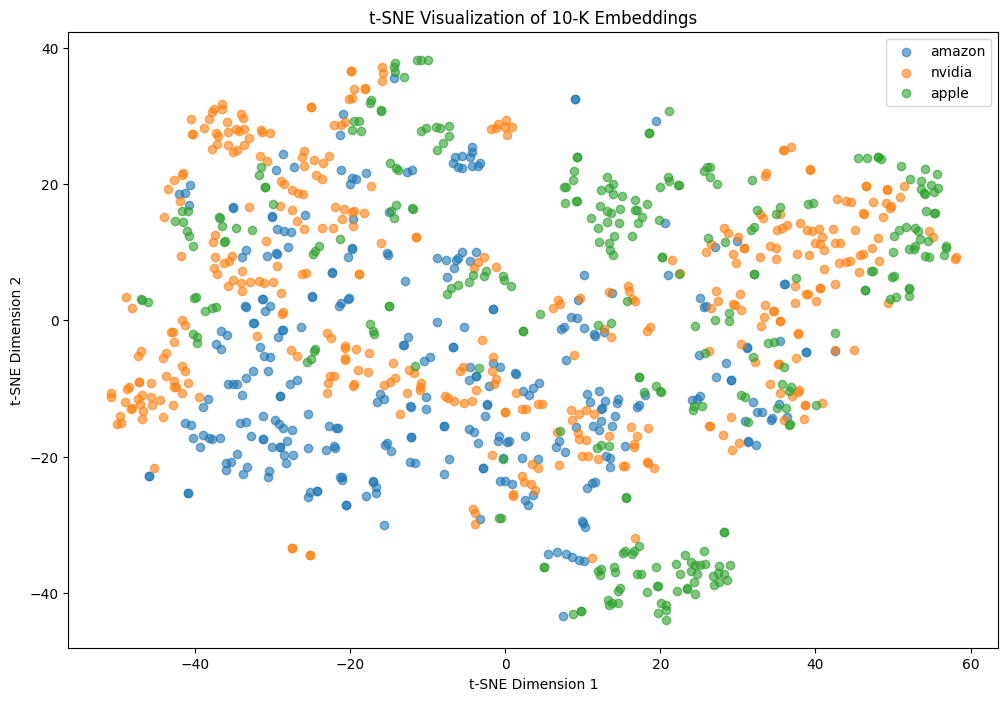

In [72]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# -----------------------------------
# Convert embeddings to numpy array
# -----------------------------------
embedding_matrix = np.array(embeddings)

print("Embedding matrix shape:", embedding_matrix.shape)


# -----------------------------------
# Sample subset for faster t-SNE
# -----------------------------------
sample_size = 1000

np.random.seed(42)

sample_idx = np.random.choice(
    len(embedding_matrix),
    size=sample_size,
    replace=False
)

sample_embeddings = embedding_matrix[sample_idx]

sample_metadata = [metadatas[i] for i in sample_idx]

print("Sample embeddings shape:", sample_embeddings.shape)


# -----------------------------------
# Run t-SNE
# -----------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

reduced_embeddings = tsne.fit_transform(sample_embeddings)

print("Reduced embedding shape:", reduced_embeddings.shape)


# -----------------------------------
# Create plotting dataframe
# -----------------------------------
plot_df = pd.DataFrame({
    "x": reduced_embeddings[:, 0],
    "y": reduced_embeddings[:, 1],
    "company": [m["company"] for m in sample_metadata],
    "year": [m["year"] for m in sample_metadata]
})

plot_df.head()


# -----------------------------------
# Plot t-SNE visualization
# -----------------------------------
plt.figure(figsize=(12, 8))

for company in plot_df["company"].unique():
    subset = plot_df[plot_df["company"] == company]

    plt.scatter(
        subset["x"],
        subset["y"],
        alpha=0.6,
        label=company
    )

plt.title("t-SNE Visualization of 10-K Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()